In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C://Users/User/Downloads/decision_tree.csv")

In [4]:
df['Approved'] = 1

In [9]:
X = df[['ApplicantIncome', 'Loan_Amount_Term', 'LoanAmount']]
y = df['Approved']

In [7]:
df.iloc[:200,-1] = 0

In [8]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Approved
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,0
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban,0
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,0


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [13]:
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import  accuracy_score,classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.4864864864864865

Report:
               precision    recall  f1-score   support

           0       0.59      0.31      0.41        42
           1       0.44      0.72      0.55        32

    accuracy                           0.49        74
   macro avg       0.52      0.51      0.48        74
weighted avg       0.53      0.49      0.47        74



In [15]:
from sklearn.tree import plot_tree


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

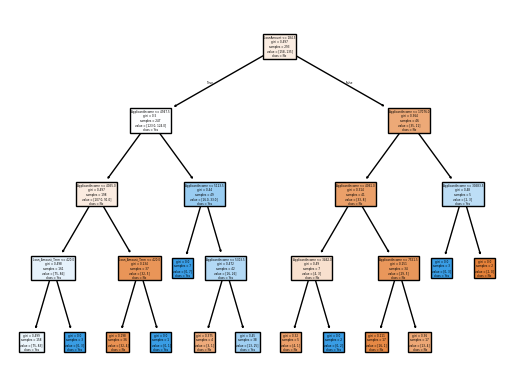

In [19]:
plot_tree(model,feature_names=X.columns,class_names=["No","Yes"],filled = True)
plt.show()

ApplicantIncome     0.738769
Loan_Amount_Term    0.090978
LoanAmount          0.170253
dtype: float64


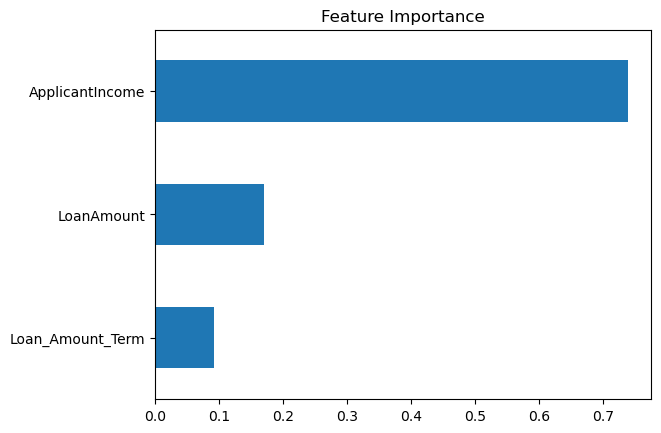

In [20]:
importance = pd.Series(model.feature_importances_, index=X.columns)

print(importance)

# Plot
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)

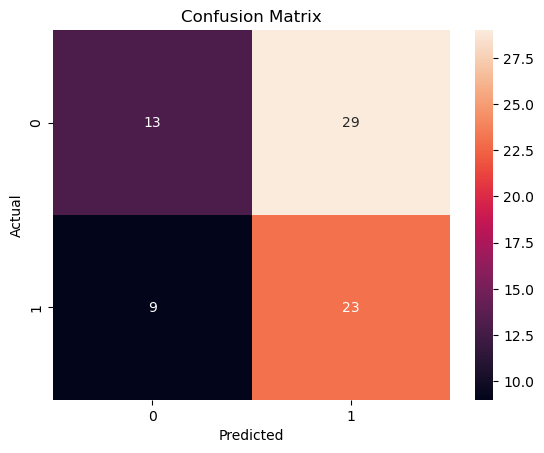

In [22]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4864864864864865

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.31      0.41        42
           1       0.44      0.72      0.55        32

    accuracy                           0.49        74
   macro avg       0.52      0.51      0.48        74
weighted avg       0.53      0.49      0.47        74



In [24]:
sample = [[6000,360,150]]

In [25]:
prediction = model.predict(sample)


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [26]:
print("Loan Approved" if prediction[0] == 1 else "Loan Rejected")

Loan Approved
